In [24]:
# Import Library
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc

In [25]:
# Load Dataset
data = pd.read_excel("Dataset_Kualitas_Air_1000.xlsx")
data.columns = data.columns.str.strip()

print(data.head())

     Tanggal  Temperatur    pH    DO   BOD   COD  TSS   TDS
0 2014-03-09        26.0  7.07  5.37  2.14  15.9   32   480
1 2014-03-09        25.9  6.99  5.44  2.14  16.0   32   480
2 2014-03-09        25.8  6.92  5.54  2.14  16.0   32   480
3 2014-03-09        25.7  6.69  5.60  2.18  16.0   32   480
4 2014-03-09        26.5  6.36  3.90  3.10  26.0   52  1001


In [26]:
data_mentah = data.copy()

In [27]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     1000 non-null   datetime64[ns]
 1   Temperatur  1000 non-null   float64       
 2   pH          1000 non-null   float64       
 3   DO          1000 non-null   float64       
 4   BOD         1000 non-null   float64       
 5   COD         1000 non-null   float64       
 6   TSS         1000 non-null   int64         
 7   TDS         1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 62.6 KB


,Tanggal,Temperatur,pH,DO,BOD,COD,TSS,TDS
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2020-01-22 00:31:40.800000256,28.448500,5.924750,3.636240,4.126690,29.540800,61.794000,1092.252000
min,2014-03-09 00:00:00,25.700000,5.000000,2.000000,1.330000,15.900000,32.000000,480.000000
25%,2017-03-04 00:00:00,27.500000,5.000000,2.730000,2.990000,25.000000,50.000000,1000.000000
50%,2020-03-02 00:00:00,27.800000,6.250000,3.900000,3.450000,26.900000,55.000000,1040.000000
75%,2023-03-04 00:00:00,29.300000,6.420000,4.400000,5.635000,33.300000,70.000000,1160.000000
max,2025-08-18 00:00:00,31.500000,7.720000,5.600000,6.500000,45.000000,120.000000,1600.000000
std,NaN,1.422597,0.679444,0.995495,1.486878,6.245881,16.946703,140.063236


In [28]:
# Preprocessing
fitur = ["Temperatur", "pH", "DO", "BOD", "COD", "TSS", "TDS"]

data[fitur] = data[fitur].apply(pd.to_numeric, errors="coerce")

imputer = SimpleImputer(strategy="mean")
data[fitur] = imputer.fit_transform(data[fitur])

print("Missing value setelah imputasi:")
print(data[fitur].isnull().sum())

Missing value setelah imputasi:
Temperatur    0
pH            0
DO            0
BOD           0
COD           0
TSS           0
TDS           0
dtype: int64


In [29]:
# =====================================================
# PENANGANAN DUPLIKASI
# =====================================================
print("=== 1. PENANGANAN DUPLIKASI ===")
dup_before = data.duplicated().sum()
print(f"Jumlah data duplikat sebelum: {dup_before}")

# Proses Hapus Duplikat
data = data.drop_duplicates().reset_index(drop=True)

dup_after = data.duplicated().sum()
print(f"Jumlah data duplikat sesudah: {dup_after}")
print(f"Total baris data sekarang: {len(data)}")
print("-" * 30)

=== 1. PENANGANAN DUPLIKASI ===
Jumlah data duplikat sebelum: 69
Jumlah data duplikat sesudah: 0
Total baris data sekarang: 931
------------------------------


In [30]:
# =====================================================
# PENANGANAN OUTLIER (IQR Capping)
# =====================================================
print("=== 2. PENANGANAN OUTLIER ===")

# Tampilan sebelum (statistik deskriptif)
print("Statistik (Max) sebelum handling outlier:")
print(data[fitur].max())

# Proses Capping Outlier
for col in fitur:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping: Nilai di atas upper diubah jadi upper, di bawah lower jadi lower
    data[col] = np.clip(data[col], lower_bound, upper_bound)

print("\nStatistik (Max) sesudah handling outlier:")
print(data[fitur].max())
print("-" * 30)

=== 2. PENANGANAN OUTLIER ===
Statistik (Max) sebelum handling outlier:
Temperatur      31.50
pH               7.72
DO               5.60
BOD              6.50
COD             45.00
TSS            120.00
TDS           1600.00
dtype: float64

Statistik (Max) sesudah handling outlier:
Temperatur      31.50
pH               7.72
DO               5.60
BOD              6.50
COD             45.00
TSS            100.00
TDS           1400.00
dtype: float64
------------------------------


In [31]:
# =====================================================================
# PENENTUAN LABEL KUALITAS AIR BERDASARKAN KEPMEN LH 115/2003 & PP 22/2021
# =====================================================================

# BAKU MUTU PP 22/2021 KELAS II
BM = {
    "pH_min": 6,
    "pH_max": 9,
    "DO": 4,        # Batas minimum oksigen terlarut
    "BOD": 3,
    "COD": 25,
    "TSS": 50,
    "TDS": 1000,
    "Temperatur": 3
}

# Konstanta Pendukung Perhitungan IP
TEMP_ALAMI = 28
C_MAKS_DO = 7.5  # Batas saturasi oksigen jenuh teoretis air murni pada kondisi tropis Pontianak

# =====================================================================
# FUNGSI HITUNG IP (TERKOREKSI TOTAL KEPMEN LH 115/2003)
# =====================================================================
def hitung_ip(row):
    rasio_baru = []

    # 1. PARAMETER pH (Metode Rentang Khusus)
    L_min = BM["pH_min"]
    L_max = BM["pH_max"]
    L_mid = (L_min + L_max) / 2

    if row["pH"] < L_mid:
        r_ph = (L_mid - row["pH"]) / (L_mid - L_min)
    else:
        r_ph = (row["pH"] - L_mid) / (L_max - L_mid)
    
    # Pengerem Logaritma jika Rasio pH > 1.0
    if r_ph > 1.0:
        r_ph = 1.0 + 5 * np.log10(r_ph)
    rasio_baru.append(r_ph)


    # 2. PARAMETER DO (Menggunakan Rumus Khusus Parameter Terbalik)
    # Rumus: (C_maks - C_i) / (C_maks - L_ij)
    r_do = (C_MAKS_DO - row["DO"]) / (C_MAKS_DO - BM["DO"])
    
    # Pengerem Logaritma jika Rasio DO > 1.0
    if r_do > 1.0:
        r_do = 1.0 + 5 * np.log10(r_do)
    rasio_baru.append(r_do)


    # 3. PARAMETER AKUMULATIF LINEAR (BOD, COD, TSS, TDS)
    for p in ["BOD", "COD", "TSS", "TDS"]:
        r_linear = row[p] / BM[p]
        
        # Pengerem Logaritma jika Rasio Akumulatif > 1.0
        if r_linear > 1.0:
            r_linear = 1.0 + 5 * np.log10(r_linear)
        rasio_baru.append(r_linear)


    # 4. PARAMETER TEMPERATUR (Deviasi Absolut terhadap Suhu Alami)
    dev_temp = abs(row["Temperatur"] - TEMP_ALAMI)
    r_temp = dev_temp / BM["Temperatur"]
    
    # Pengerem Logaritma jika Rasio Temperatur > 1.0
    if r_temp > 1.0:
        r_temp = 1.0 + 5 * np.log10(r_temp)
    rasio_baru.append(r_temp)


    # =================================================================
    # AGREGASI NILAI INDEKS PENCEMARAN (IP)
    # =================================================================
    R = np.mean(rasio_baru)  # Nilai rata-rata rasio baru keseluruhan
    M = np.max(rasio_baru)   # Nilai maksimum rasio baru keseluruhan

    return np.sqrt((M**2 + R**2) / 2)

In [32]:
data["IP"] = data.apply(hitung_ip, axis=1)

print("Kolom IP berhasil dibuat")
print(data[["IP"]].head())

def label_ip_binary(ip):
    return 0 if ip <= 1 else 1

data["Label_IP"] = data["IP"].apply(label_ip_binary)

print(data["Label_IP"].value_counts())

Kolom IP berhasil dibuat
         IP
0  0.691709
1  0.696225
2  0.699540
3  0.715073
4  1.014182
Label_IP
1    513
0    418
Name: count, dtype: int64


In [33]:
# Time Shift (Target = Kondisi Berikutnya)
# Geser label untuk target waktu berikutnya (t+1)
data["Target"] = data["Label_IP"].shift(-1)

# Buang baris terakhir yang target-nya NaN
data = data.dropna().reset_index(drop=True)

# Tampilkan SEMUA FITUR + Label + Target
kolom_time_aware = fitur + ["Label_IP", "Target"]
data[kolom_time_aware].head(10)

,Temperatur,pH,DO,BOD,COD,TSS,TDS,Label_IP,Target
0,26.0,7.07,5.37,2.14,15.9,32.0,760.0,0,0.0
1,25.9,6.99,5.44,2.14,16.0,32.0,760.0,0,0.0
2,25.8,6.92,5.54,2.14,16.0,32.0,760.0,0,0.0
3,25.7,6.69,5.60,2.18,16.0,32.0,760.0,0,1.0
4,26.5,6.36,3.90,3.10,26.0,52.0,1001.0,1,1.0
5,27.0,5.94,3.48,3.82,28.0,57.0,1041.0,1,1.0
6,27.5,5.32,3.12,4.47,30.1,62.0,1081.0,1,1.0
7,28.1,5.00,2.81,5.08,32.2,67.0,1121.0,1,1.0
8,28.7,5.00,2.50,5.92,34.3,72.0,1161.0,1,1.0
9,29.2,5.00,2.00,6.50,36.5,77.0,1202.0,1,1.0


In [34]:
# =====================================================
# STANDARISASI (StandardScaler)
# =====================================================
from sklearn.preprocessing import StandardScaler
import os

print("=== 3. STANDARISASI DATA ===")
print("Sampel data sebelum standarisasi (5 baris):")
print(data[fitur].head())

# Inisialisasi Scaler (Ganti ke StandardScaler)
scaler = StandardScaler()

# Proses Fit & Transform
data[fitur] = scaler.fit_transform(data[fitur])

# Tentukan Folder Output
OUTPUT_DIR = "HASIL_PERCOBAAN_XGBOOST"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# SIMPAN SCALER UNTUK STREAMLIT
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler_kualitas_air.pkl")

print("\nSampel data sesudah standarisasi (5 baris):")
print(data[fitur].head())
print("✅ Scaler berhasil disimpan sebagai 'scaler_kualitas_air.pkl'")
print("-" * 30)

=== 3. STANDARISASI DATA ===
Sampel data sebelum standarisasi (5 baris):
   Temperatur    pH    DO   BOD   COD   TSS     TDS
0        26.0  7.07  5.37  2.14  15.9  32.0   760.0
1        25.9  6.99  5.44  2.14  16.0  32.0   760.0
2        25.8  6.92  5.54  2.14  16.0  32.0   760.0
3        25.7  6.69  5.60  2.18  16.0  32.0   760.0
4        26.5  6.36  3.90  3.10  26.0  52.0  1001.0

Sampel data sesudah standarisasi (5 baris):
   Temperatur        pH        DO       BOD       COD       TSS       TDS
0   -1.745077  1.697744  1.768266 -1.361930 -2.233749 -1.967826 -2.770919
1   -1.815529  1.581259  1.838373 -1.361930 -2.217524 -1.967826 -2.770919
2   -1.885980  1.479336  1.938527 -1.361930 -2.217524 -1.967826 -2.770919
3   -1.956432  1.144443  1.998620 -1.335145 -2.217524 -1.967826 -2.770919
4   -1.392820  0.663945  0.296003 -0.719087 -0.595060 -0.634290 -0.752209
✅ Scaler berhasil disimpan sebagai 'scaler_kualitas_air.pkl'
------------------------------


In [35]:
# Split Data Latih & Uji
X = data[fitur]
y = data["Target"]

split_idx = int(0.9 * len(data))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(X_train.shape, X_test.shape)

(837, 7) (93, 7)


In [36]:
# Training Model
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=4,
    learning_rate=0.01,
    n_estimators=100,
    subsample=1.0,
    colsample_bytree=0.9,
    gamma=0,              
    min_child_weight=1,  
    random_state=42
)

model.fit(X_train, y_train)
print("Model selesai dilatih")

Model selesai dilatih


In [37]:
# SIMPAN MODEL FINAL UTAMA
model_final = model

# SIMPAN DATA TEST FINAL
X_test_final = X_test.copy()
y_test_final = y_test.copy()

In [38]:
# Evaluasi Model
y_pred = model.predict(X_test)
print("Akurasi:", round(accuracy_score(y_test, y_pred), 2))
print(classification_report(
    y_test, y_pred,
    target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"]
))

Akurasi: 0.82
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.83      0.81      0.82        47
    Tidak Memenuhi       0.81      0.83      0.82        46

          accuracy                           0.82        93
         macro avg       0.82      0.82      0.82        93
      weighted avg       0.82      0.82      0.82        93



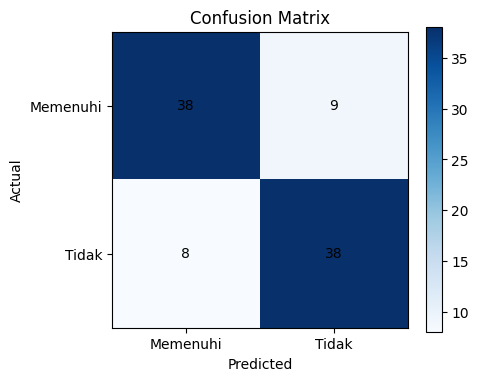

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0,1], ["Memenuhi", "Tidak"])
plt.yticks([0,1], ["Memenuhi", "Tidak"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

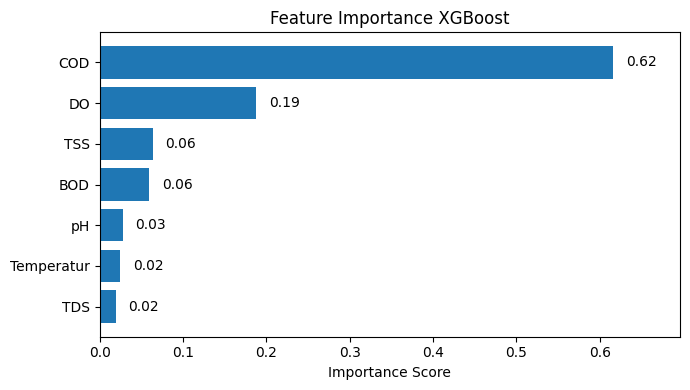

In [40]:
# Feature Importance
importances = model_final.feature_importances_

feature_names = np.array(fitur)

idx = np.argsort(importances)

plt.figure(figsize=(7,4))
bars = plt.barh(feature_names[idx], importances[idx])

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.015, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center')

plt.xlim(0, max(importances) + 0.08)
plt.xlabel("Importance Score")
plt.title("Feature Importance XGBoost")
plt.tight_layout()
plt.show()

Nilai AUC: 0.8185


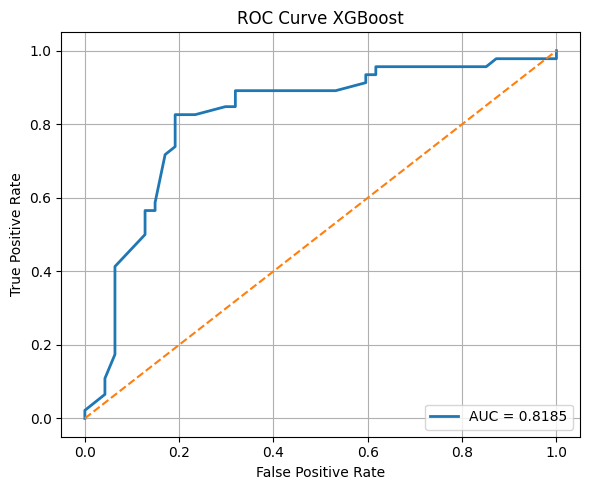

In [41]:
# =========================================
# ROC CURVE & AUC
# =========================================

# Probabilitas prediksi
y_prob = model.predict_proba(X_test)[:, 1]

# Hitung ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Hitung AUC
roc_auc = auc(fpr, tpr)

print("Nilai AUC:", round(roc_auc, 4))

# Plot ROC Curve
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2,
         label=f'AUC = {roc_auc:.4f}')

# Garis diagonal random classifier
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve XGBoost")
plt.legend(loc="lower right")

plt.grid(True)
plt.tight_layout()

# Tampilkan
plt.show()

In [42]:
joblib.dump(model, "model_xgboost_kualitas_air.pkl")

metadata = {
    "fitur": fitur,
    "labeling": "Indeks Pencemaran (Binary)",
    "kelas": {
        0: "Memenuhi Baku Mutu",
        1: "Tidak Memenuhi Baku Mutu"
    },
    "baku_mutu": "PP No.22 Tahun 2021 Kelas II",
    "time_aware": True
}

joblib.dump(metadata, "metadata_model.pkl")

print("Model & metadata siap dipakai di Streamlit")

Model & metadata siap dipakai di Streamlit


# Percobaan Kodingan



=== HASIL SKENARIO 1: BASELINE ===
    Akurasi  Precision    Recall  F1-Score  Skenario
0  0.806452   0.804348  0.804348  0.804348  Baseline

=== HASIL SKENARIO 2: MAX_DEPTH ===
    Akurasi  Precision    Recall  F1-Score      Skenario  Value
0  0.806452   0.804348  0.804348  0.804348   max_depth=1      1
1  0.806452   0.804348  0.804348  0.804348   max_depth=2      2
3  0.806452   0.804348  0.804348  0.804348   max_depth=4      4
4  0.806452   0.804348  0.804348  0.804348   max_depth=5      5
5  0.806452   0.804348  0.804348  0.804348   max_depth=6      6
6  0.806452   0.804348  0.804348  0.804348   max_depth=7      7
7  0.806452   0.804348  0.804348  0.804348   max_depth=8      8
2  0.795699   0.787234  0.804348  0.795699   max_depth=3      3
8  0.795699   0.800000  0.782609  0.791209   max_depth=9      9
9  0.795699   0.800000  0.782609  0.791209  max_depth=10     10


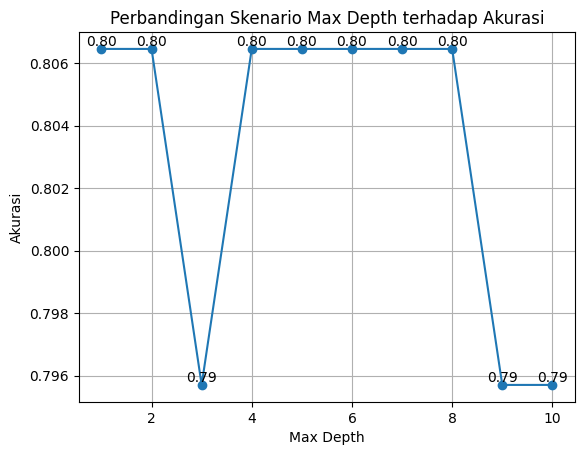


=== HASIL SKENARIO 3: LEARNING RATE ===
    Akurasi  Precision    Recall  F1-Score            Skenario  Value
0  0.806452   0.804348  0.804348  0.804348  learning_rate=0.01   0.01
2  0.806452   0.804348  0.804348  0.804348  learning_rate=0.03   0.03
1  0.795699   0.787234  0.804348  0.795699  learning_rate=0.02   0.02
3  0.795699   0.787234  0.804348  0.795699  learning_rate=0.04   0.04
4  0.795699   0.787234  0.804348  0.795699  learning_rate=0.05   0.05
5  0.795699   0.787234  0.804348  0.795699   learning_rate=0.1   0.10
6  0.795699   0.787234  0.804348  0.795699   learning_rate=0.2   0.20
7  0.774194   0.804878  0.717391  0.758621   learning_rate=0.3   0.30
8  0.763441   0.800000  0.695652  0.744186   learning_rate=0.4   0.40
9  0.763441   0.800000  0.695652  0.744186   learning_rate=0.5   0.50


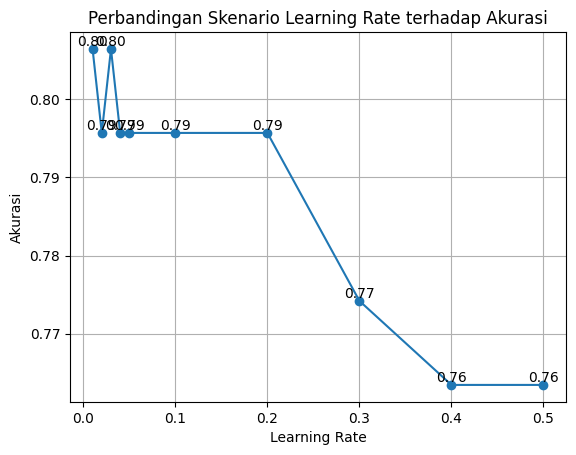


=== HASIL SKENARIO 4: N_ESTIMATORS ===
    Akurasi  Precision    Recall  F1-Score           Skenario  Value
0  0.806452   0.804348  0.804348  0.804348   n_estimators=100    100
1  0.795699   0.787234  0.804348  0.795699   n_estimators=200    200
2  0.795699   0.787234  0.804348  0.795699   n_estimators=300    300
3  0.795699   0.787234  0.804348  0.795699   n_estimators=400    400
4  0.795699   0.787234  0.804348  0.795699   n_estimators=500    500
5  0.795699   0.787234  0.804348  0.795699   n_estimators=600    600
6  0.795699   0.787234  0.804348  0.795699   n_estimators=700    700
7  0.795699   0.787234  0.804348  0.795699   n_estimators=800    800
8  0.795699   0.787234  0.804348  0.795699   n_estimators=900    900
9  0.795699   0.787234  0.804348  0.795699  n_estimators=1000   1000


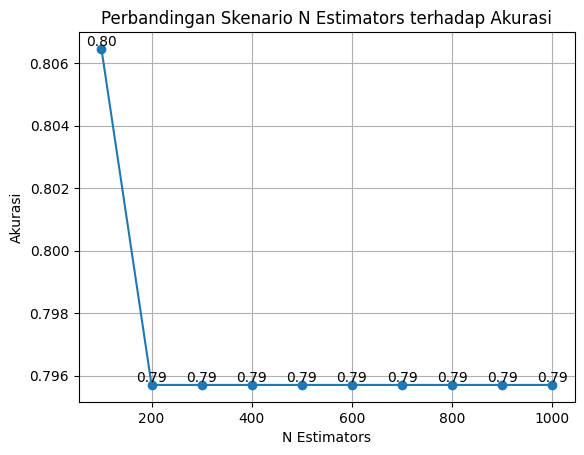


=== HASIL SKENARIO 5: SAMPLING ===
     Akurasi  Precision    Recall  F1-Score  Subsample  Colsample  \
34  0.817204   0.808511  0.826087  0.817204        1.0        1.0   
33  0.817204   0.808511  0.826087  0.817204        1.0        0.9   
29  0.817204   0.808511  0.826087  0.817204        0.9        1.0   
25  0.806452   0.804348  0.804348  0.804348        0.9        0.6   
20  0.806452   0.804348  0.804348  0.804348        0.8        0.6   
21  0.806452   0.804348  0.804348  0.804348        0.8        0.7   
22  0.806452   0.804348  0.804348  0.804348        0.8        0.8   
23  0.806452   0.804348  0.804348  0.804348        0.8        0.9   
24  0.806452   0.804348  0.804348  0.804348        0.8        1.0   
27  0.806452   0.804348  0.804348  0.804348        0.9        0.8   
26  0.806452   0.804348  0.804348  0.804348        0.9        0.7   
18  0.806452   0.804348  0.804348  0.804348        0.7        0.9   
28  0.806452   0.804348  0.804348  0.804348        0.9        0.9  

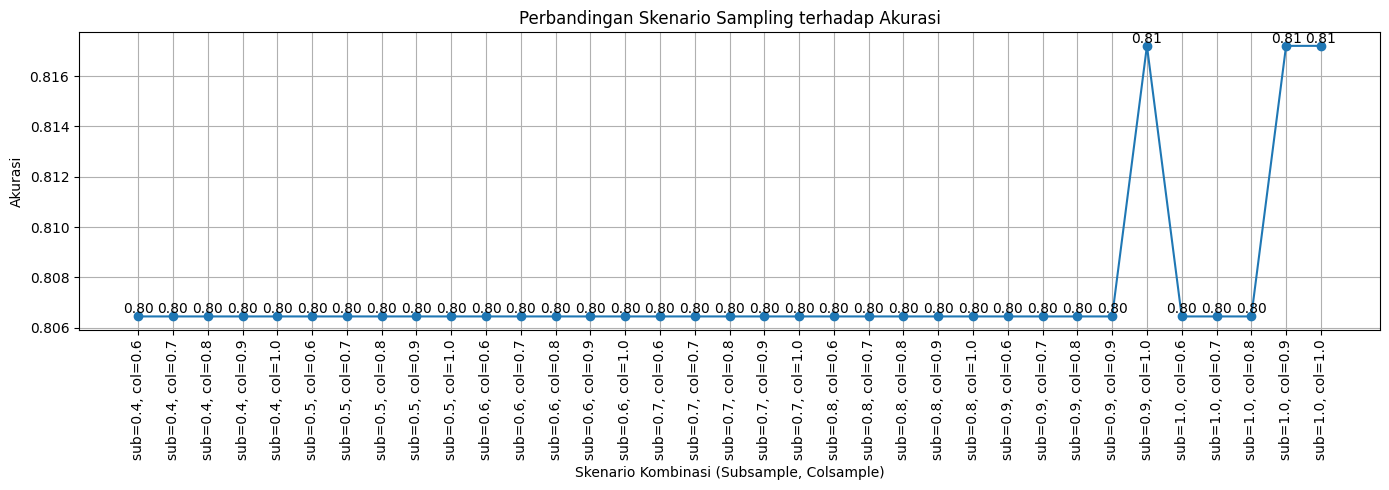


=== HASIL SKENARIO 6: GAMMA ===
    Akurasi  Precision    Recall  F1-Score   Skenario  Value
0  0.806452   0.804348  0.804348  0.804348    gamma=0    0.0
1  0.806452   0.804348  0.804348  0.804348  gamma=0.1    0.1
2  0.806452   0.804348  0.804348  0.804348  gamma=0.2    0.2
3  0.806452   0.804348  0.804348  0.804348  gamma=0.3    0.3
4  0.806452   0.804348  0.804348  0.804348  gamma=0.5    0.5
5  0.806452   0.804348  0.804348  0.804348    gamma=1    1.0
6  0.806452   0.804348  0.804348  0.804348    gamma=2    2.0
7  0.806452   0.804348  0.804348  0.804348    gamma=3    3.0
8  0.806452   0.804348  0.804348  0.804348    gamma=5    5.0
9  0.806452   0.804348  0.804348  0.804348   gamma=10   10.0


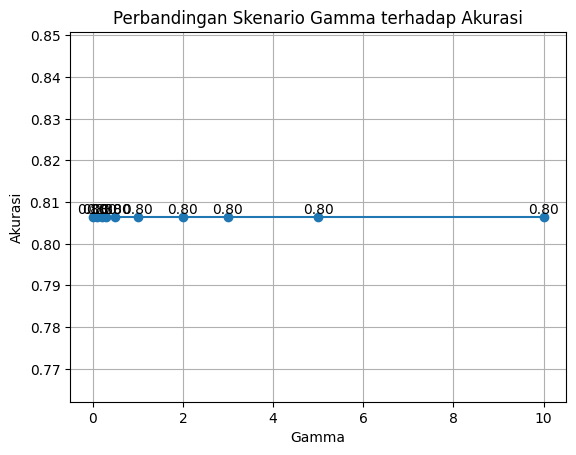


=== HASIL SKENARIO 7: MIN_CHILD_WEIGHT ===
    Akurasi  Precision    Recall  F1-Score             Skenario  Value
0  0.806452   0.804348  0.804348  0.804348   min_child_weight=1      1
1  0.806452   0.804348  0.804348  0.804348   min_child_weight=2      2
2  0.806452   0.804348  0.804348  0.804348   min_child_weight=3      3
3  0.806452   0.804348  0.804348  0.804348   min_child_weight=4      4
4  0.806452   0.804348  0.804348  0.804348   min_child_weight=5      5
5  0.806452   0.804348  0.804348  0.804348   min_child_weight=6      6
6  0.806452   0.804348  0.804348  0.804348   min_child_weight=7      7
7  0.806452   0.804348  0.804348  0.804348   min_child_weight=8      8
8  0.806452   0.804348  0.804348  0.804348   min_child_weight=9      9
9  0.806452   0.804348  0.804348  0.804348  min_child_weight=10     10


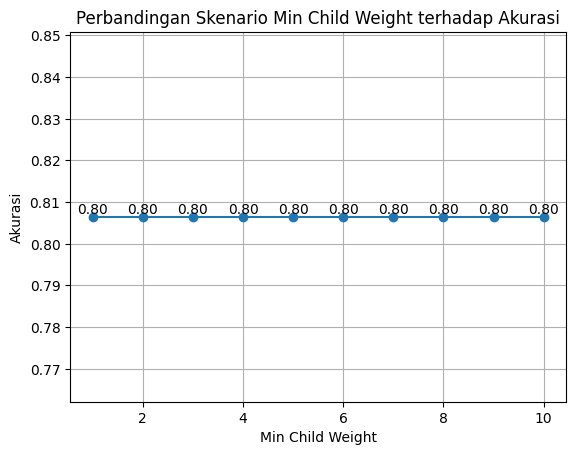

In [43]:
# ================================================================
# PERCOBAAN HYPERPARAMETER TUNING (MURNI 2 DESIMAL TANPA PEMBULATAN)
# ================================================================
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Fungsi evaluasi biar tidak berulang
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Akurasi": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

# --- SKENARIO 1: BASELINE ---
baseline_results = []
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=3,
    learning_rate=0.01,
    n_estimators=100,
    subsample=1.0,
    colsample_bytree=0.8,
    random_state=42
)
res = evaluate_model(model, X_train, y_train, X_test, y_test).copy()
res["Skenario"] = "Baseline"
baseline_results.append(res)
df_baseline = pd.DataFrame(baseline_results)

print("\n=== HASIL SKENARIO 1: BASELINE ===")
print(df_baseline)


# --- SKENARIO 2: MAX_DEPTH ---
depth_results = []
list_depth = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in list_depth:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=depth,
        learning_rate=0.05,
        n_estimators=300,
        subsample=1.0,
        colsample_bytree=0.8,
        random_state=42
    )
    res = evaluate_model(model, X_train, y_train, X_test, y_test).copy()
    res["Skenario"] = f"max_depth={depth}"
    res["Value"] = depth
    depth_results.append(res)

df_depth = pd.DataFrame(depth_results)
print("\n=== HASIL SKENARIO 2: MAX_DEPTH ===")
print(df_depth.sort_values(by="Akurasi", ascending=False))

# Visualisasi Max Depth
plt.figure()
plt.plot(df_depth["Value"], df_depth["Akurasi"], marker='o')
for i, txt in enumerate(df_depth["Akurasi"]):
    # Trik slicing [:4] memastikan mengambil '0' '.' '7' '9' dari string murni desimal
    txt_murni = f"{txt:.4f}"[:4] if isinstance(txt, float) else str(txt)
    plt.text(
        df_depth["Value"][i],
        df_depth["Akurasi"][i],
        txt_murni,
        ha='center',
        va='bottom'
    )
plt.title("Perbandingan Skenario Max Depth terhadap Akurasi")
plt.xlabel("Max Depth")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()


# --- SKENARIO 3: LEARNING RATE ---
lr_results = []
list_lr = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

for lr in list_lr:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=3,
        learning_rate=lr,
        n_estimators=300,
        subsample=1.0,
        colsample_bytree=0.8,
        random_state=42
    )
    res = evaluate_model(model, X_train, y_train, X_test, y_test).copy()
    res["Skenario"] = f"learning_rate={lr}"
    res["Value"] = lr
    lr_results.append(res)

df_lr = pd.DataFrame(lr_results)
print("\n=== HASIL SKENARIO 3: LEARNING RATE ===")
print(df_lr.sort_values(by="Akurasi", ascending=False))

# Visualisasi Learning Rate
plt.figure()
plt.plot(df_lr["Value"], df_lr["Akurasi"], marker='o')
for i, txt in enumerate(df_lr["Akurasi"]):
    txt_murni = f"{txt:.4f}"[:4] if isinstance(txt, float) else str(txt)
    plt.text(
        df_lr["Value"][i],
        df_lr["Akurasi"][i],
        txt_murni,
        ha='center',
        va='bottom'
    )
plt.title("Perbandingan Skenario Learning Rate terhadap Akurasi")
plt.xlabel("Learning Rate")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()


# --- SKENARIO 4: N_ESTIMATORS ---
est_results = []
list_est = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

for n in list_est:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=3,
        learning_rate=0.05,
        n_estimators=n,
        subsample=1.0,
        colsample_bytree=0.8,
        random_state=42
    )
    res = evaluate_model(model, X_train, y_train, X_test, y_test).copy()
    res["Skenario"] = f"n_estimators={n}"
    res["Value"] = n
    est_results.append(res)

df_est = pd.DataFrame(est_results)
print("\n=== HASIL SKENARIO 4: N_ESTIMATORS ===")
print(df_est.sort_values(by="Akurasi", ascending=False))

# Visualisasi N Estimators
plt.figure()
plt.plot(df_est["Value"], df_est["Akurasi"], marker='o')
for i, txt in enumerate(df_est["Akurasi"]):
    txt_murni = f"{txt:.4f}"[:4] if isinstance(txt, float) else str(txt)
    plt.text(
        df_est["Value"][i],
        df_est["Akurasi"][i],
        txt_murni,
        ha='center',
        va='bottom'
    )
plt.title("Perbandingan Skenario N Estimators terhadap Akurasi")
plt.xlabel("N Estimators")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()


# --- SKENARIO 5: SAMPLING (SUB-SAMPLE & COL-SAMPLE) ---
sampling_results = []
for subsample in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    for colsample in [0.6, 0.7, 0.8, 0.9, 1.0]:
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            max_depth=4,
            learning_rate=0.01,
            n_estimators=100,
            subsample=subsample,
            colsample_bytree=colsample,
            random_state=42
        )
        res = evaluate_model(model, X_train, y_train, X_test, y_test).copy()
        res["Subsample"] = subsample
        res["Colsample"] = colsample
        res["Skenario"] = f"sub={subsample}, col={colsample}"
        sampling_results.append(res)

df_sampling = pd.DataFrame(sampling_results)
print("\n=== HASIL SKENARIO 5: SAMPLING ===")
print(df_sampling.sort_values(by="Akurasi", ascending=False))

# Visualisasi Sampling
plt.figure(figsize=(14, 5))
plt.plot(df_sampling["Skenario"], df_sampling["Akurasi"], marker='o')
for i, txt in enumerate(df_sampling["Akurasi"]):
    txt_murni = f"{f'{txt:.4f}'[:4]}" if isinstance(txt, float) else str(txt)
    plt.text(
        df_sampling["Skenario"][i],
        df_sampling["Akurasi"][i],
        txt_murni,
        ha='center',
        va='bottom'
    )
plt.title("Perbandingan Skenario Sampling terhadap Akurasi")
plt.xlabel("Skenario Kombinasi (Subsample, Colsample)")
plt.ylabel("Akurasi")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()


# --- SKENARIO 6: GAMMA ---
gamma_results = []
list_gamma = [0, 0.1, 0.2, 0.3, 0.5, 1, 2, 3, 5, 10]

for gamma in list_gamma:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=3,
        learning_rate=0.01,
        n_estimators=100,
        subsample=1.0,
        colsample_bytree=0.8,
        gamma=gamma,
        random_state=42
    )
    res = evaluate_model(model, X_train, y_train, X_test, y_test).copy()
    res["Skenario"] = f"gamma={gamma}"
    res["Value"] = gamma
    gamma_results.append(res)

df_gamma = pd.DataFrame(gamma_results)
print("\n=== HASIL SKENARIO 6: GAMMA ===")
print(df_gamma.sort_values(by="Akurasi", ascending=False))

# Visualisasi Gamma
plt.figure()
plt.plot(df_gamma["Value"], df_gamma["Akurasi"], marker='o')
for i, txt in enumerate(df_gamma["Akurasi"]):
    txt_murni = f"{txt:.4f}"[:4] if isinstance(txt, float) else str(txt)
    plt.text(
        df_gamma["Value"][i],
        df_gamma["Akurasi"][i],
        txt_murni,
        ha='center',
        va='bottom'
    )
plt.title("Perbandingan Skenario Gamma terhadap Akurasi")
plt.xlabel("Gamma")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()


# --- SKENARIO 7: MIN_CHILD_WEIGHT ---
mcw_results = []
list_mcw = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for mcw in list_mcw:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=3,
        learning_rate=0.01,
        n_estimators=100,
        subsample=1.0,
        colsample_bytree=0.8,
        gamma=0,
        min_child_weight=mcw,
        random_state=42
    )
    res = evaluate_model(model, X_train, y_train, X_test, y_test).copy()
    res["Skenario"] = f"min_child_weight={mcw}"
    res["Value"] = mcw
    mcw_results.append(res)

df_mcw = pd.DataFrame(mcw_results)
print("\n=== HASIL SKENARIO 7: MIN_CHILD_WEIGHT ===")
print(df_mcw.sort_values(by="Akurasi", ascending=False))

# Visualisasi Min Child Weight
plt.figure()
plt.plot(df_mcw["Value"], df_mcw["Akurasi"], marker='o')
for i, txt in enumerate(df_mcw["Akurasi"]):
    txt_murni = f"{txt:.4f}"[:4] if isinstance(txt, float) else str(txt)
    plt.text(
        df_mcw["Value"][i],
        df_mcw["Akurasi"][i],
        txt_murni,
        ha='center',
        va='bottom'
    )
plt.title("Perbandingan Skenario Min Child Weight terhadap Akurasi")
plt.xlabel("Min Child Weight")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()

In [44]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# ================================
# DATA
# ================================
X = data[fitur]
y = data["Target"]

# Skenario split
splits = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

# Menyimpan hasil
hasil = []

# ================================
# LOOP SEMUA SKENARIO
# ================================
for split in splits:
    split_idx = int(split * len(data))
    
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]
    
    # Model
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=3,
        learning_rate=0.01,
        n_estimators=100,
        gamma=0,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=0.9,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    
    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    
    print("\n==============================")
    print(f"SPLIT {int(split*100)}% : {int((1-split)*100)}%")
    print("==============================")
    print("Akurasi:", round(acc, 4))
    
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"]
    ))
    
    # Simpan hasil
    hasil.append({
        "Data Latih (%)": int(split*100),
        "Data Uji (%)": int((1-split)*100),
        "Akurasi": round(acc*100, 2)
    })

# ================================
# TABEL HASIL
# ================================
df_hasil = pd.DataFrame(hasil)
print("\n=== RINGKASAN HASIL ===")
print(df_hasil)


SPLIT 90% : 9%
Akurasi: 0.8172

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.83      0.81      0.82        47
    Tidak Memenuhi       0.81      0.83      0.82        46

          accuracy                           0.82        93
         macro avg       0.82      0.82      0.82        93
      weighted avg       0.82      0.82      0.82        93


SPLIT 80% : 19%
Akurasi: 0.7849

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.80      0.80      0.80        98
    Tidak Memenuhi       0.77      0.77      0.77        88

          accuracy                           0.78       186
         macro avg       0.78      0.78      0.78       186
      weighted avg       0.78      0.78      0.78       186


SPLIT 70% : 30%
Akurasi: 0.7706

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.81      0.74    

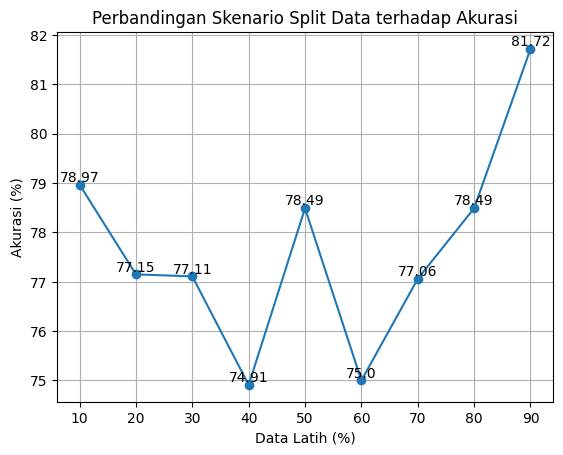

In [45]:
import matplotlib.pyplot as plt

# ================================
# VISUALISASI LINE CHART
# ================================
plt.figure()

# Plot line + marker titik
plt.plot(df_hasil["Data Latih (%)"], df_hasil["Akurasi"], marker='o')

# Tambahkan label di setiap titik
for i, txt in enumerate(df_hasil["Akurasi"]):
    plt.text(
        df_hasil["Data Latih (%)"][i],
        df_hasil["Akurasi"][i],
        str(txt),
        ha='center',
        va='bottom'
    )

# Judul dan label sumbu
plt.title("Perbandingan Skenario Split Data terhadap Akurasi")
plt.xlabel("Data Latih (%)")
plt.ylabel("Akurasi (%)")

# Grid (background kotak-kotak)
plt.grid(True)

# Tampilkan plot
plt.show()

In [46]:
# =====================================================
# EXPORT HASIL FINAL PENELITIAN (PERBAIKAN KOLOM & DESIMAL)
# =====================================================

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# ===============================
# BUAT FOLDER OUTPUT
# ===============================
OUTPUT_DIR = "HASIL_PELATIHAN_XGBOOST"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===============================
# 1. DATA MENTAH (5 BARIS)
# ===============================
data_mentah.head(5).to_excel(
    f"{OUTPUT_DIR}/01_data_mentah_5_baris.xlsx",
    index=False
)

# ===============================
# 2. CLASSIFICATION REPORT
# ===============================
# Prediksi
y_pred = model_final.predict(X_test_final)

# Simpan hasil final (biar tidak ketimpa)
y_pred_final = y_pred.copy()

# Export classification report
report = classification_report(
    y_test_final,
    y_pred_final,
    target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"],
    output_dict=True
)

pd.DataFrame(report).transpose().to_excel(
    f"{OUTPUT_DIR}/02_classification_report.xlsx"
)

# ===============================
# 3. CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test_final, y_pred_final)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0,1], ["Memenuhi", "Tidak"])
plt.yticks([0,1], ["Memenuhi", "Tidak"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_confusion_matrix.png")
plt.close()

# ===============================
# 4. FEATURE IMPORTANCE
# ===============================
importances = model_final.feature_importances_
feature_names = np.array(fitur)
idx = np.argsort(importances)

plt.figure(figsize=(7,4))
bars = plt.barh(feature_names[idx], importances[idx])

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.015,
             bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             va='center')

plt.xlim(0, max(importances) + 0.08)
plt.xlabel("Importance Score")
plt.title("Feature Importance XGBoost")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/04_feature_importance.png")
plt.close()

# ===============================
# 5. HASIL SKENARIO (TABEL)
# ===============================
df_hasil.to_excel(f"{OUTPUT_DIR}/05_split_data.xlsx", index=False)
df_baseline.to_excel(f"{OUTPUT_DIR}/06_baseline.xlsx", index=False)
df_depth.to_excel(f"{OUTPUT_DIR}/07_max_depth.xlsx", index=False)
df_lr.to_excel(f"{OUTPUT_DIR}/08_learning_rate.xlsx", index=False)
df_est.to_excel(f"{OUTPUT_DIR}/09_n_estimators.xlsx", index=False)
df_sampling.to_excel(f"{OUTPUT_DIR}/10_sampling.xlsx", index=False)

# ===============================
# 6. GRAFIK SKENARIO
# ===============================

# --- SPLIT DATA ---
plt.figure()
plt.plot(df_hasil["Data Latih (%)"], df_hasil["Akurasi"], marker='o')
for i in range(len(df_hasil)):
    # Slicing murni 2 desimal tanpa pembulatan ke atas
    txt_murni = f"{df_hasil['Akurasi'][i]:.4f}"[:4] if isinstance(df_hasil["Akurasi"][i], float) else str(df_hasil["Akurasi"][i])
    plt.text(df_hasil["Data Latih (%)"][i],
             df_hasil["Akurasi"][i],
             txt_murni,
             ha='center', va='bottom')
plt.title("Split Data dan Akurasi")
plt.xlabel("Data Latih (%)")
plt.ylabel("Akurasi (%)")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/11_split_data.png")
plt.close()

# --- MAX DEPTH ---
df_depth["depth"] = df_depth["Skenario"].str.extract(r'(\d+)').astype(int)

plt.figure()
plt.plot(df_depth["depth"], df_depth["Akurasi"], marker='o') # DIUBAH: 'Accuracy' -> 'Akurasi'
for i in range(len(df_depth)):
    txt_murni = f"{df_depth['Akurasi'][i]:.4f}"[:4] if isinstance(df_depth["Akurasi"][i], float) else str(df_depth["Akurasi"][i])
    plt.text(df_depth["depth"][i],
             df_depth["Akurasi"][i],
             txt_murni,
             ha='center', va='bottom')
plt.title("Max Depth dan Akurasi")
plt.xlabel("Max Depth")
plt.ylabel("Akurasi")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/12_max_depth.png")
plt.close()

# --- LEARNING RATE ---
df_lr["lr"] = df_lr["Skenario"].str.extract(r'([\d.]+)').astype(float)

plt.figure()
plt.plot(df_lr["lr"], df_lr["Akurasi"], marker='o') # DIUBAH: 'Accuracy' -> 'Akurasi'
for i in range(len(df_lr)):
    txt_murni = f"{df_lr['Akurasi'][i]:.4f}"[:4] if isinstance(df_lr["Akurasi"][i], float) else str(df_lr["Akurasi"][i])
    plt.text(df_lr["lr"][i],
             df_lr["Akurasi"][i],
             txt_murni,
             ha='center', va='bottom')
plt.title("Learning Rate dan Akurasi")
plt.xlabel("Learning Rate")
plt.ylabel("Akurasi")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/13_learning_rate.png")
plt.close()

# --- N ESTIMATORS ---
df_est["n"] = df_est["Skenario"].str.extract(r'(\d+)').astype(int)

plt.figure()
plt.plot(df_est["n"], df_est["Akurasi"], marker='o') # DIUBAH: 'Accuracy' -> 'Akurasi'
for i in range(len(df_est)):
    txt_murni = f"{df_est['Akurasi'][i]:.4f}"[:4] if isinstance(df_est["Akurasi"][i], float) else str(df_est["Akurasi"][i])
    plt.text(df_est["n"][i],
             df_est["Akurasi"][i],
             txt_murni,
             ha='center', va='bottom')
plt.title("n_estimators dan Akurasi")
plt.xlabel("n_estimators")
plt.ylabel("Akurasi")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/14_n_estimators.png")
plt.close()

# --- SAMPLING (TOP 10) ---
df_sampling_sorted = df_sampling.sort_values(by="Akurasi", ascending=False).head(10) # DIUBAH: 'Accuracy' -> 'Akurasi'

plt.figure()
plt.plot(range(len(df_sampling_sorted)), df_sampling_sorted["Akurasi"], marker='o') # DIUBAH: 'Accuracy' -> 'Akurasi'

for i in range(len(df_sampling_sorted)):
    txt_murni = f"{df_sampling_sorted['Akurasi'].iloc[i]:.4f}"[:4] if isinstance(df_sampling_sorted["Akurasi"].iloc[i], float) else str(df_sampling_sorted["Akurasi"].iloc[i])
    plt.text(i,
             df_sampling_sorted["Akurasi"].iloc[i],
             txt_murni,
             ha='center', va='bottom')

plt.xticks(range(len(df_sampling_sorted)),
           df_sampling_sorted["Skenario"],
           rotation=45)

plt.title("Sampling Top 10")
plt.xlabel("Skenario")
plt.ylabel("Akurasi")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/15_sampling.png")
plt.close()

# ===============================
# 7. SIMPAN MODEL
# ===============================
joblib.dump(model_final, f"{OUTPUT_DIR}/16_model_xgboost.pkl")

# ===============================
# 8. ZIP SEMUA HASIL
# ===============================
ZIP_NAME = "HASIL_PELATIHAN_XGBOOST.zip"

with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, file), arcname=file)

# ===============================
# ROC CURVE
# ===============================

from sklearn.metrics import roc_curve, auc

# Probabilitas prediksi
y_prob = model_final.predict_proba(X_test_final)[:, 1]

# Hitung ROC
fpr, tpr, thresholds = roc_curve(y_test_final, y_prob)

# Hitung AUC
roc_auc = auc(fpr, tpr)

print("Nilai AUC:", round(roc_auc, 4))

# Plot ROC
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.4f}'
)

# Garis diagonal
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve XGBoost")
plt.legend(loc="lower right")

plt.grid(True)
plt.tight_layout()

# Simpan ke folder penelitian
plt.savefig(f"{OUTPUT_DIR}/16_roc_curve.png")

plt.close()

print("✅ EXPORT SELESAI")
print(f"📦 File: {ZIP_NAME}")

Nilai AUC: 0.8185
✅ EXPORT SELESAI
📦 File: HASIL_PELATIHAN_XGBOOST.zip
